# 1. Ingestão de Dados e Análise Exploratória (EDA)

In [1]:
import pandas as pd

# 1. Carregar a base de dados
caminho_csv = '/content/base_simulada.csv'

# Lemos o arquivo informando que o separador é ponto e vírgula
df = pd.read_csv(caminho_csv, delimiter=';', encoding='utf-8')

# 2. Visualizar as primeiras linhas (O display deixa a tabela bonita no Jupyter)
print("Amostra dos Dados:")
display(df.head())

# 3. Analisar a distribuição das classes de risco (Entendendo o balanceamento da base)
print("\n--- Distribuição dos Níveis de Risco ---")
print(df['situacao'].value_counts())

Amostra dos Dados:


,frase,situacao
0,sinto uma dor forte no peito e falta de ar,alto risco
1,estou com uma pressão no peito que não passa,alto risco
2,tive uma dor no peito que foi pro braço esquerdo,alto risco
3,comecei a suar frio e meu peito ficou apertado,alto risco
4,estou com falta de ar mesmo parado e uma dor n...,alto risco



--- Distribuição dos Níveis de Risco ---
situacao
alto risco     20
medio risco    17
baixo risco    13
Name: count, dtype: int64


# 2. Tradução Matemática (TF-IDF)

In [2]:
from sklearn.feature_extraction.text import TfidfVectorizer

vetorizador = TfidfVectorizer()

matriz_textos = vetorizador.fit_transform(df['frase'])

print("Tamanho da nossa nova matriz de números:")
print(matriz_textos.shape)

Tamanho da nossa nova matriz de números:
(50, 169)


# 3. Treinamento da Inteligência Artificial (Decision Tree)

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

X_treino, X_teste, y_treino, y_teste = train_test_split(matriz_textos, df['situacao'], test_size=0.2, random_state=42)

modelo = DecisionTreeClassifier(random_state=42)

modelo.fit(X_treino, y_treino)

print("A Inteligência Artificial foi treinada com sucesso!")

A Inteligência Artificial foi treinada com sucesso!


# 4. Avaliação do Modelo (A Prova Final)

--- Boletim de Notas da Inteligência Artificial ---

              precision    recall  f1-score   support

  alto risco       0.33      0.67      0.44         3
 baixo risco       1.00      0.67      0.80         3
 medio risco       0.50      0.25      0.33         4

    accuracy                           0.50        10
   macro avg       0.61      0.53      0.53        10
weighted avg       0.60      0.50      0.51        10



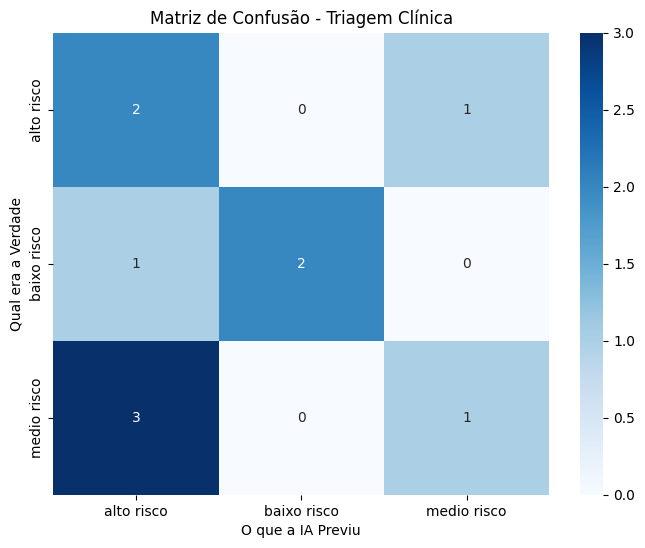

In [4]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

previsoes = modelo.predict(X_teste)

print("--- Boletim de Notas da Inteligência Artificial ---\n")
print(classification_report(y_teste, previsoes))

matriz = confusion_matrix(y_teste, previsoes)
plt.figure(figsize=(8, 6))
sns.heatmap(matriz, annot=True, fmt='d', cmap='Blues',
            xticklabels=modelo.classes_,
            yticklabels=modelo.classes_)
plt.title('Matriz de Confusão - Triagem Clínica')
plt.xlabel('O que a IA Previu')
plt.ylabel('Qual era a Verdade')
plt.show()